In [5]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Set random seed and define project paths

In this step, we:
- set a random seed for reproducibility
- define the dataset and output folder paths
- create output directories if they do not already exist

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

project_root = Path.cwd()
data_dir = project_root / "data" / "natural_images"
figures_dir = project_root / "outputs" / "figures"
tables_dir = project_root / "outputs" / "tables"
model_dir = project_root / "outputs" / "model"

for folder in [figures_dir, tables_dir, model_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Data directory:", data_dir)
print("Exists:", data_dir.exists())

Project root: c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\LSTM Implementation Project - Image Classification with CNN-LSTM
Data directory: c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_2\LSTM Implementation Project - Image Classification with CNN-LSTM\data\natural_images
Exists: True


## 3. Inspect dataset classes

In this step, we identify the class folders inside the dataset directory.
Each subfolder represents one image category.

In [7]:
class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
Number of classes: 8


## 4. Count images in each class

In this step, we count how many image files are available in each class folder.
This helps us understand the dataset distribution and check for class imbalance.

In [8]:
image_counts = {}

for class_name in class_names:
    class_path = data_dir / class_name
    count = len([f for f in class_path.iterdir() if f.is_file()])
    image_counts[class_name] = count

df_counts = pd.DataFrame({
    "class_name": list(image_counts.keys()),
    "image_count": list(image_counts.values())
}).sort_values("class_name")

df_counts

,class_name,image_count
0,airplane,727
1,car,968
2,cat,885
3,dog,702
4,flower,843
5,fruit,1000
6,motorbike,788
7,person,986


## 5. Visualize class distribution

In this step, we create a bar chart to visualize the number of images in each class.
This helps us quickly assess whether the dataset is balanced across categories.

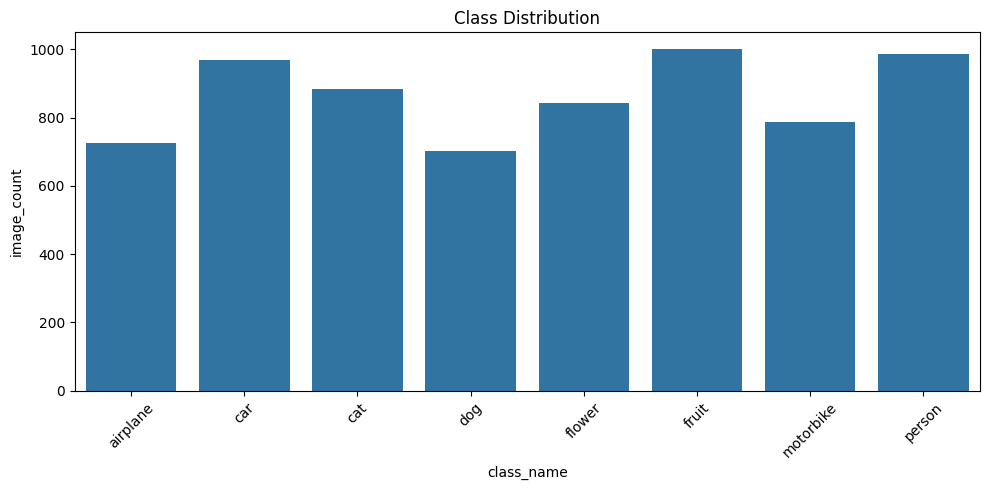

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_counts, x="class_name", y="image_count")
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig(figures_dir / "class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Display sample images from each class

In this step, we display one sample image from each class to visually inspect the dataset.
This helps confirm that the images are loading correctly and that the class folders contain the expected content.

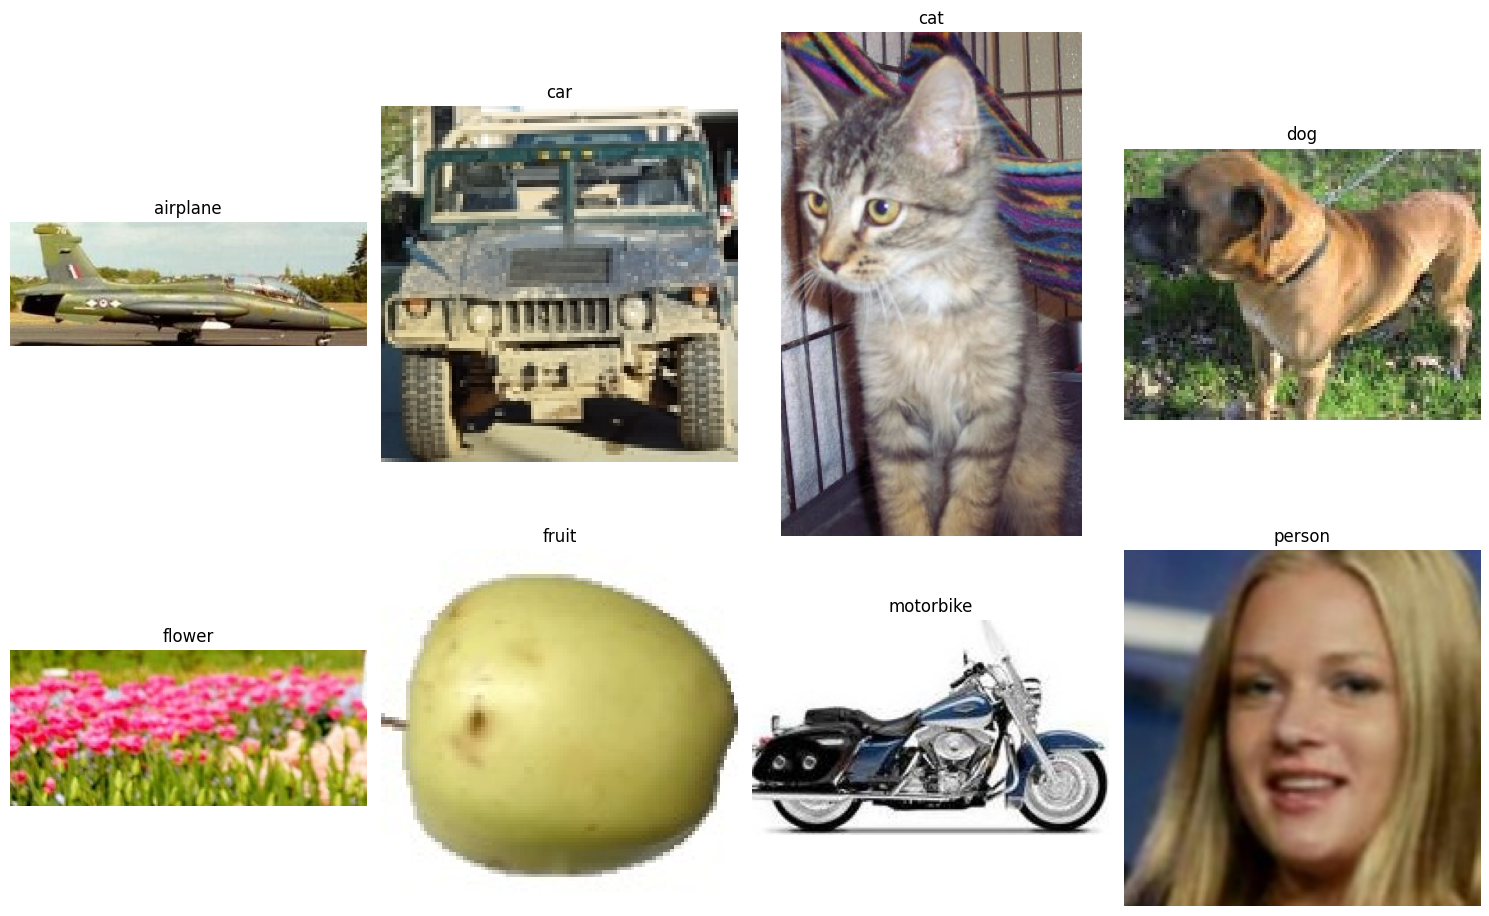

In [10]:
plt.figure(figsize=(15, 10))

for i, class_name in enumerate(class_names):
    class_path = data_dir / class_name
    image_files = [f for f in class_path.iterdir() if f.is_file()]
    sample_image = Image.open(image_files[0])

    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.savefig(figures_dir / "sample_images.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Build a dataframe of image file paths and labels

In this step, we create a dataframe containing:
- the full path of each image
- the corresponding class label

This structured format makes it easier to split the dataset into training, validation, and test sets.

In [11]:
filepaths = []
labels = []

valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

for class_name in class_names:
    class_path = data_dir / class_name
    for file in class_path.iterdir():
        if file.is_file() and file.suffix.lower() in valid_extensions:
            filepaths.append(str(file))
            labels.append(class_name)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

print("Total images:", len(df))
df.head()

Total images: 6899


,filepath,label
0,c:\Users\dubey\Documents\UC_GitLab\Spring_2026...,airplane
1,c:\Users\dubey\Documents\UC_GitLab\Spring_2026...,airplane
2,c:\Users\dubey\Documents\UC_GitLab\Spring_2026...,airplane
3,c:\Users\dubey\Documents\UC_GitLab\Spring_2026...,airplane
4,c:\Users\dubey\Documents\UC_GitLab\Spring_2026...,airplane


## 8. Verify class distribution from the dataframe

In this step, we verify the number of images per class using the dataframe.
This confirms that the dataframe correctly represents the dataset.

In [12]:
df["label"].value_counts().sort_index()

label
airplane      727
car           968
cat           885
dog           702
flower        843
fruit        1000
motorbike     788
person        986
Name: count, dtype: int64

## 9. Split the dataset into training, validation, and test sets

In this step, we split the dataframe into:
- training set
- validation set
- test set

We use stratified splitting so that each set preserves the class distribution.

In [13]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["label"].value_counts().sort_index())

Train shape: (4829, 2)
Validation shape: (1035, 2)
Test shape: (1035, 2)

Train distribution:
label
airplane     509
car          678
cat          619
dog          491
flower       590
fruit        700
motorbike    552
person       690
Name: count, dtype: int64

Validation distribution:
label
airplane     109
car          145
cat          133
dog          105
flower       127
fruit        150
motorbike    118
person       148
Name: count, dtype: int64

Test distribution:
label
airplane     109
car          145
cat          133
dog          106
flower       126
fruit        150
motorbike    118
person       148
Name: count, dtype: int64


## 10. Define image and training parameters

In this step, we define:
- target image size
- batch size
- number of output classes

These parameters will be used during preprocessing and model training.

In [14]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = len(class_names)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: (128, 128)
Batch size: 32
Number of classes: 8


## 11. Create image data generators

In this step, we create image data generators for:
- training data with augmentation
- validation data without augmentation
- test data without augmentation

Data augmentation helps improve model generalization by creating varied versions of training images.

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

print("Training and test image generators created successfully.")

Training and test image generators created successfully.


## 12. Create training, validation, and test generators from the dataframe

In this step, we create generators that read images from file paths and their corresponding labels.
These generators will feed batches of images into the model during training and evaluation.

In [16]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 4829 validated image filenames belonging to 8 classes.
Found 1035 validated image filenames belonging to 8 classes.
Found 1035 validated image filenames belonging to 8 classes.


## 13. Store the class index mapping

In this step, we store the mapping between class names and numeric indices.
This will help us later when interpreting predictions and plotting results.

In [17]:
class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

print("Class indices:", class_indices)

Class indices: {'airplane': 0, 'car': 1, 'cat': 2, 'dog': 3, 'flower': 4, 'fruit': 5, 'motorbike': 6, 'person': 7}


## 14. Inspect one batch of images and labels

In this step, we load one batch from the training generator and check:
- image batch shape
- label batch shape

This helps confirm that the input pipeline is working correctly.

In [18]:
images, targets = next(train_generator)

print("Image batch shape:", images.shape)
print("Target batch shape:", targets.shape)

Image batch shape: (32, 128, 128, 3)
Target batch shape: (32, 8)


## 15. Display a few preprocessed images from one training batch

In this step, we display a few images from the training generator along with their class labels.
This helps verify that preprocessing and augmentation are working correctly.

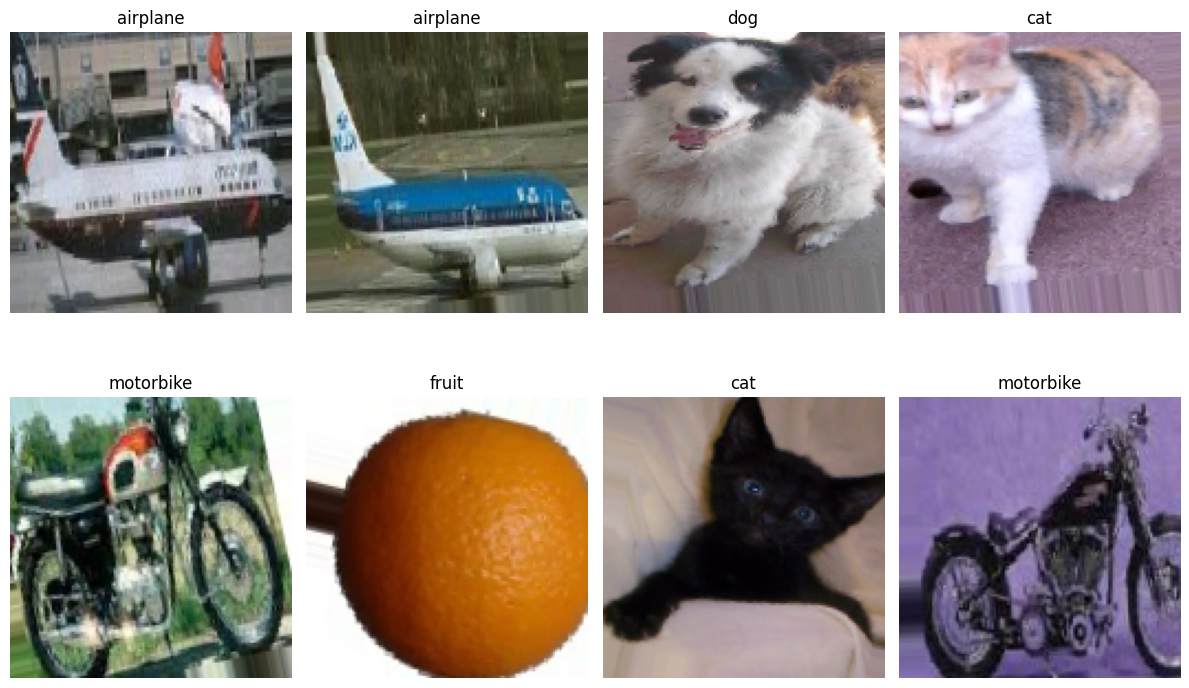

In [19]:
plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    label_index = np.argmax(targets[i])
    plt.title(idx_to_class[label_index])
    plt.axis("off")

plt.tight_layout()
plt.savefig(figures_dir / "preprocessed_batch_samples.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Build a CNN-LSTM hybrid model

In this step, we build a hybrid deep learning model for image classification.

Model logic:
- CNN layers extract visual features from images
- the extracted feature maps are reshaped into a sequence
- an LSTM layer processes the sequence
- dense layers produce the final class probabilities

This architecture satisfies the project requirement of using LSTM techniques for image classification.

In [20]:
cnn_lstm_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    # CNN feature extractor
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    # Reshape CNN feature maps into a sequence for LSTM
    layers.Reshape((16 * 16, 128)),

    # LSTM for sequential feature learning
    layers.LSTM(64),

    # Classification head
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

print("CNN-LSTM model created successfully.")

CNN-LSTM model created successfully.


## 17. View the CNN-LSTM model summary

In this step, we display the model summary to inspect:
- layer sequence
- output shapes
- number of trainable parameters

This helps verify that the CNN feature maps are correctly reshaped before being passed to the LSTM layer.

In [21]:
cnn_lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,904 (597.28 KB)

 Trainable params: 152,456 (595.53 KB)

 Non-trainable params: 448 (1.75 KB)

## 18. Compile the CNN-LSTM model

In this step, we compile the model by defining:
- the optimizer
- the loss function
- the evaluation metric

For this multi-class image classification problem, categorical cross-entropy is an appropriate loss function.

In [22]:
cnn_lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 19. Define training callbacks

In this step, we define callbacks to improve training efficiency and reduce overfitting:

- EarlyStopping stops training when validation loss stops improving
- ModelCheckpoint saves the best model
- ReduceLROnPlateau lowers the learning rate when progress slows

In [23]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = callbacks.ModelCheckpoint(
    filepath=str(model_dir / "best_cnn_lstm_model.keras"),
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

callback_list = [early_stopping, model_checkpoint, reduce_lr]

print("Callbacks created successfully.")

Callbacks created successfully.


## 20. Train the CNN-LSTM model

In this step, we train the CNN-LSTM model using the training generator and validate it on the validation generator.

We use callbacks to:
- stop early if validation performance stops improving
- save the best model
- reduce the learning rate when needed

In [24]:
history = cnn_lstm_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callback_list,
    verbose=1
)

Epoch 1/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 64s 406ms/step - accuracy: 0.4384 - loss: 1.5801 - val_accuracy: 0.1072 - val_loss: 2.4161 - learning_rate: 0.0010
Epoch 2/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 47s 307ms/step - accuracy: 0.5829 - loss: 1.1912 - val_accuracy: 0.1729 - val_loss: 2.5979 - learning_rate: 0.0010
Epoch 3/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 48s 314ms/step - accuracy: 0.6339 - loss: 1.0640 - val_accuracy: 0.4744 - val_loss: 1.4542 - learning_rate: 0.0010
Epoch 4/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 47s 312ms/step - accuracy: 0.6529 - loss: 0.9875 - val_accuracy: 0.6386 - val_loss: 0.9662 - learning_rate: 0.0010
Epoch 5/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 48s 314ms/step - accuracy: 0.6836 - loss: 0.9130 - val_accuracy: 0.5411 - val_loss: 1.6479 - learning_rate: 0.0010
Epoch 6/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 47s 313ms/step - accuracy: 0.7119 - loss: 0.8289 - val_accuracy: 0.6029 - val_loss: 1.2343 - learning_rate: 0.0010
Epoch 7/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 47s 311ms/step - accuracy: 0.7

## 21. Plot training and validation performance

In this step, we visualize:
- training accuracy vs validation accuracy
- training loss vs validation loss

These plots help us understand the learning behavior of the CNN-LSTM model across epochs.

In [25]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.438393,1.580124,0.107246,2.416094,0.0010
1,0.582936,1.191199,0.172947,2.597929,0.0010
2,0.633879,1.064022,0.474396,1.454185,0.0010
3,0.652930,0.987504,0.638647,0.966228,0.0010
4,0.683578,0.912969,0.541063,1.647935,0.0010
5,0.711949,0.828868,0.602899,1.234345,0.0010
6,0.738248,0.761689,0.677295,0.861073,0.0010
7,0.762891,0.675592,0.596135,1.380847,0.0010
8,0.772210,0.658277,0.248309,3.099334,0.0010
9,0.736591,0.756848,0.613527,1.235536,0.0010


## 22. Plot training and validation accuracy and loss

In this step, we plot the model's training and validation accuracy and loss across epochs.
These visualizations help us assess learning progress, convergence, and possible overfitting.

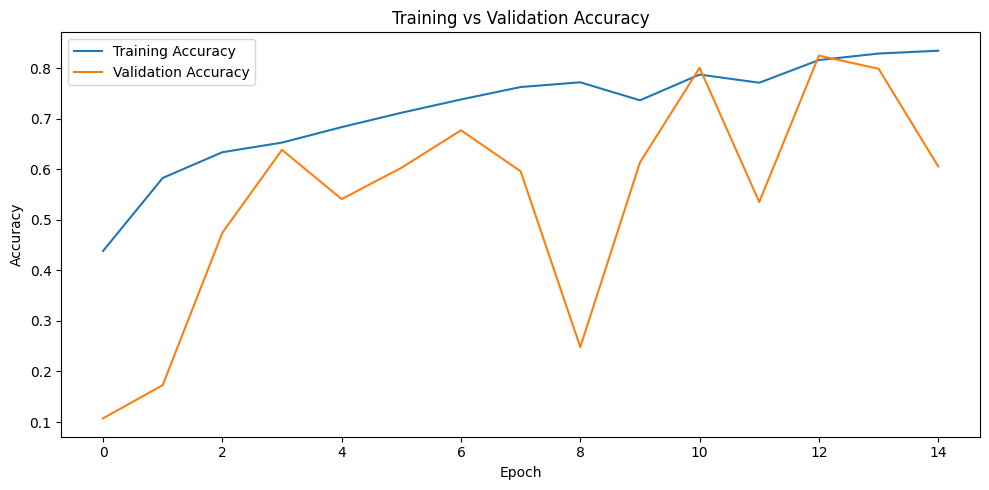

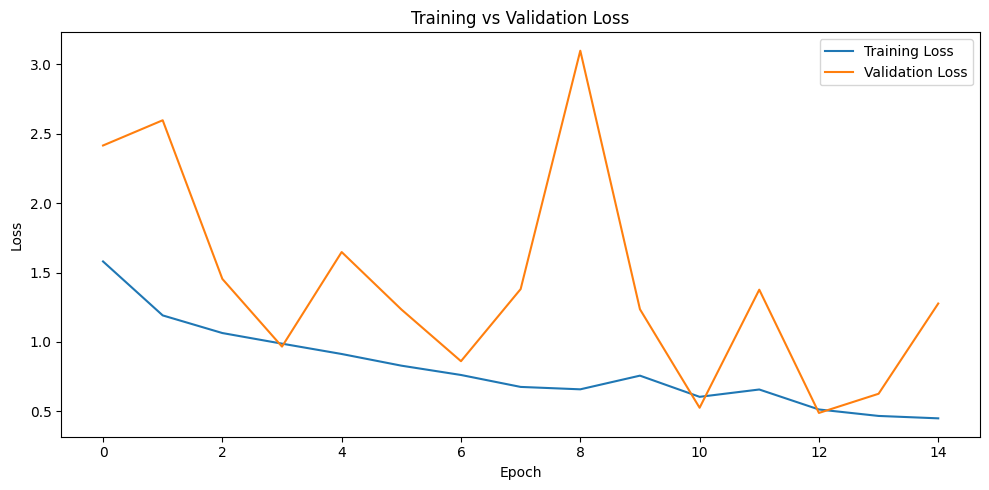

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 23. Evaluate the CNN-LSTM model on the test set

In this step, we evaluate the trained model on the test dataset.
This gives us the final test loss and test accuracy, which reflect how well the model generalizes to unseen data.

In [27]:
test_loss, test_accuracy = cnn_lstm_model.evaluate(test_generator, verbose=1)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.8097 - loss: 0.4972
Test Loss: 0.4972
Test Accuracy: 0.8097


## 24. Generate predictions on the test set

In this step, we generate class predictions for the test dataset.
These predictions will be used to calculate detailed evaluation metrics such as the confusion matrix, precision, recall, and F1-score.

In [28]:
test_generator.reset()
y_prob = cnn_lstm_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step
Predictions generated successfully.
Number of predictions: 1035


## 25. Generate the classification report

In this step, we calculate detailed classification metrics for each class, including:
- precision
- recall
- F1-score
- support

This gives a deeper understanding of model performance beyond overall accuracy.

In [29]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
airplane,0.842593,0.834862,0.838710,109.000000
car,0.923664,0.834483,0.876812,145.000000
cat,0.673913,0.466165,0.551111,133.000000
dog,0.520833,0.471698,0.495050,106.000000
flower,0.782313,0.912698,0.842491,126.000000
fruit,0.961290,0.993333,0.977049,150.000000
motorbike,0.739726,0.915254,0.818182,118.000000
person,0.887500,0.959459,0.922078,148.000000
accuracy,0.809662,0.809662,0.809662,0.809662
macro avg,0.791479,0.798494,0.790185,1035.000000


## 26. Save the classification report and create the confusion matrix

In this step, we:
- save the classification report as a CSV file
- print a readable classification report
- compute and visualize the confusion matrix

The confusion matrix helps identify which classes are being confused by the model.

              precision    recall  f1-score   support

    airplane       0.84      0.83      0.84       109
         car       0.92      0.83      0.88       145
         cat       0.67      0.47      0.55       133
         dog       0.52      0.47      0.50       106
      flower       0.78      0.91      0.84       126
       fruit       0.96      0.99      0.98       150
   motorbike       0.74      0.92      0.82       118
      person       0.89      0.96      0.92       148

    accuracy                           0.81      1035
   macro avg       0.79      0.80      0.79      1035
weighted avg       0.80      0.81      0.80      1035



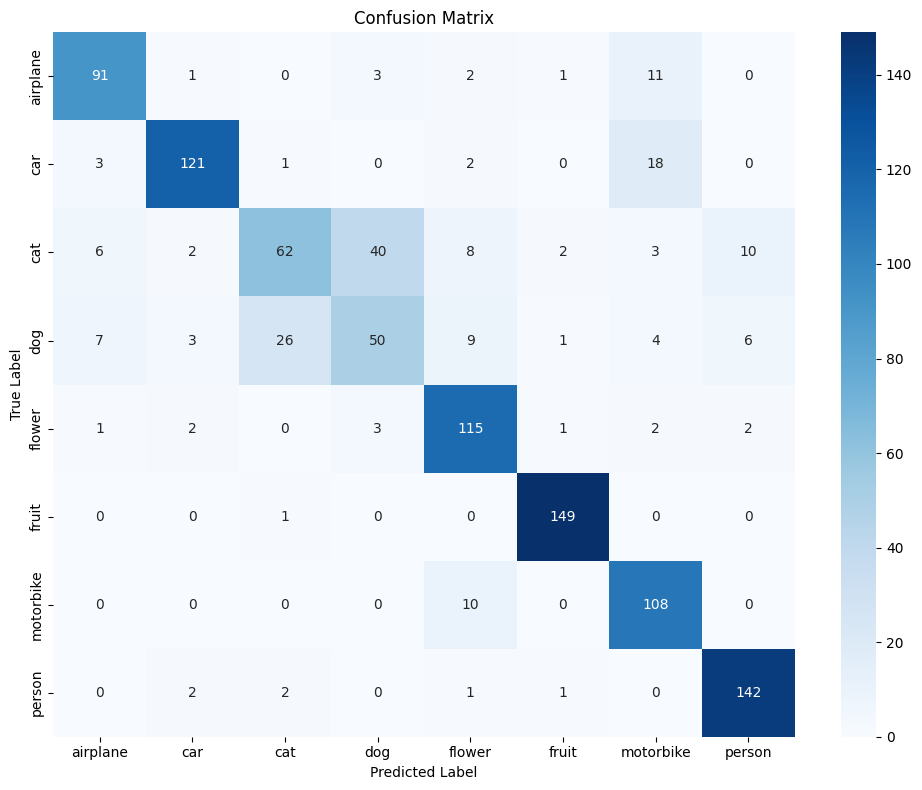

In [30]:
# Save classification report
report_df.to_csv(tables_dir / "classification_report.csv", index=True)

# Print readable classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## 27. Create a summary table of key evaluation metrics

In this step, we create a compact summary of the model's key performance metrics.
This table will be useful for the final project report.

In [31]:
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro"
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted"
)

metrics_summary_df = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-Score",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score"
    ],
    "Value": [
        test_accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted
    ]
})

metrics_summary_df["Value"] = metrics_summary_df["Value"].round(4)

metrics_summary_df.to_csv(tables_dir / "metrics_summary.csv", index=False)
metrics_summary_df

,Metric,Value
0,Test Accuracy,0.8097
1,Macro Precision,0.7915
2,Macro Recall,0.7985
3,Macro F1-Score,0.7902
4,Weighted Precision,0.8039
5,Weighted Recall,0.8097
6,Weighted F1-Score,0.8020


## 28. Record the baseline model performance

In this step, we record the performance of the initial CNN-LSTM model as the baseline result.
This will later be compared with a tuned version of the model for optimization analysis.

In [32]:
baseline_results = {
    "Model": "Baseline CNN-LSTM",
    "Test Accuracy": round(float(test_accuracy), 4),
    "Macro Precision": round(float(precision_macro), 4),
    "Macro Recall": round(float(recall_macro), 4),
    "Macro F1-Score": round(float(f1_macro), 4),
    "Weighted Precision": round(float(precision_weighted), 4),
    "Weighted Recall": round(float(recall_weighted), 4),
    "Weighted F1-Score": round(float(f1_weighted), 4)
}

baseline_results

{'Model': 'Baseline CNN-LSTM',
 'Test Accuracy': 0.8097,
 'Macro Precision': 0.7915,
 'Macro Recall': 0.7985,
 'Macro F1-Score': 0.7902,
 'Weighted Precision': 0.8039,
 'Weighted Recall': 0.8097,
 'Weighted F1-Score': 0.802}

## 29. Build a tuned CNN-LSTM model for optimization

In this step, we create a tuned version of the CNN-LSTM model to support optimization analysis.

Changes from the baseline model:
- increase LSTM units from 64 to 128
- slightly reduce dropout from 0.5 to 0.4

This experiment helps us assess whether a larger LSTM representation improves classification performance.

In [33]:
tuned_cnn_lstm_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    # CNN feature extractor
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),

    # Reshape feature maps into a sequence for LSTM
    layers.Reshape((16 * 16, 128)),

    # Tuned LSTM
    layers.LSTM(128),

    # Classification head
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

print("Tuned CNN-LSTM model created successfully.")

Tuned CNN-LSTM model created successfully.


## 30. Compile the tuned CNN-LSTM model

In this step, we compile the tuned model using the same optimizer, loss function, and evaluation metric as the baseline model.
This ensures that the comparison between the baseline and tuned models remains fair.

In [34]:
tuned_cnn_lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Tuned model compiled successfully.")

Tuned model compiled successfully.


## 31. Train the tuned CNN-LSTM model

In this step, we train the tuned CNN-LSTM model using the same training and validation generators.

Using the same training configuration allows a fair comparison with the baseline model.

In [35]:
tuned_early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

tuned_model_checkpoint = callbacks.ModelCheckpoint(
    filepath=str(model_dir / "best_tuned_cnn_lstm_model.keras"),
    monitor="val_loss",
    save_best_only=True
)

tuned_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

tuned_callback_list = [
    tuned_early_stopping,
    tuned_model_checkpoint,
    tuned_reduce_lr
]

tuned_history = tuned_cnn_lstm_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=tuned_callback_list,
    verbose=1
)

Epoch 1/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 57s 358ms/step - accuracy: 0.4815 - loss: 1.4752 - val_accuracy: 0.1903 - val_loss: 2.7614 - learning_rate: 0.0010
Epoch 2/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 58s 383ms/step - accuracy: 0.6364 - loss: 1.0441 - val_accuracy: 0.3014 - val_loss: 2.3671 - learning_rate: 0.0010
Epoch 3/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 58s 382ms/step - accuracy: 0.6730 - loss: 0.9296 - val_accuracy: 0.4744 - val_loss: 1.5788 - learning_rate: 0.0010
Epoch 4/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 58s 380ms/step - accuracy: 0.6941 - loss: 0.8931 - val_accuracy: 0.6010 - val_loss: 1.1235 - learning_rate: 0.0010
Epoch 5/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 57s 377ms/step - accuracy: 0.7099 - loss: 0.8113 - val_accuracy: 0.6763 - val_loss: 0.9965 - learning_rate: 0.0010
Epoch 6/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 57s 377ms/step - accuracy: 0.7420 - loss: 0.7140 - val_accuracy: 0.6155 - val_loss: 1.1130 - learning_rate: 0.0010
Epoch 7/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 56s 372ms/step - accuracy: 0.7

## 32. Evaluate the tuned CNN-LSTM model on the test set

In this step, we evaluate the tuned model on the test dataset to compare its final generalization performance with the baseline model.

In [36]:
tuned_test_loss, tuned_test_accuracy = tuned_cnn_lstm_model.evaluate(test_generator, verbose=1)

print("Tuned Test Loss:", round(tuned_test_loss, 4))
print("Tuned Test Accuracy:", round(tuned_test_accuracy, 4))

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.7768 - loss: 0.6118
Tuned Test Loss: 0.6118
Tuned Test Accuracy: 0.7768


## 33. Generate predictions and compute tuned model metrics

In this step, we generate predictions from the tuned model and calculate summary evaluation metrics for comparison with the baseline model.

In [37]:
test_generator.reset()
tuned_y_prob = tuned_cnn_lstm_model.predict(test_generator, verbose=1)
tuned_y_pred = np.argmax(tuned_y_prob, axis=1)

tuned_precision_macro, tuned_recall_macro, tuned_f1_macro, _ = precision_recall_fscore_support(
    y_true, tuned_y_pred, average="macro"
)

tuned_precision_weighted, tuned_recall_weighted, tuned_f1_weighted, _ = precision_recall_fscore_support(
    y_true, tuned_y_pred, average="weighted"
)

tuned_results = {
    "Model": "Tuned CNN-LSTM",
    "Test Accuracy": round(float(tuned_test_accuracy), 4),
    "Macro Precision": round(float(tuned_precision_macro), 4),
    "Macro Recall": round(float(tuned_recall_macro), 4),
    "Macro F1-Score": round(float(tuned_f1_macro), 4),
    "Weighted Precision": round(float(tuned_precision_weighted), 4),
    "Weighted Recall": round(float(tuned_recall_weighted), 4),
    "Weighted F1-Score": round(float(tuned_f1_weighted), 4)
}

tuned_results

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step


{'Model': 'Tuned CNN-LSTM',
 'Test Accuracy': 0.7768,
 'Macro Precision': 0.7589,
 'Macro Recall': 0.763,
 'Macro F1-Score': 0.7549,
 'Weighted Precision': 0.7764,
 'Weighted Recall': 0.7768,
 'Weighted F1-Score': 0.7709}

## 34. Compare baseline and tuned model results

In this step, we compare the baseline and tuned CNN-LSTM models using a summary table of key evaluation metrics.
This supports the optimization and insights section of the report.

In [38]:
comparison_df = pd.DataFrame([baseline_results, tuned_results])
comparison_df.to_csv(tables_dir / "baseline_vs_tuned_comparison.csv", index=False)
comparison_df

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Weighted Precision,Weighted Recall,Weighted F1-Score
0,Baseline CNN-LSTM,0.8097,0.7915,0.7985,0.7902,0.8039,0.8097,0.8020
1,Tuned CNN-LSTM,0.7768,0.7589,0.7630,0.7549,0.7764,0.7768,0.7709
